In [ ]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

# Load the job from the Hydra config package.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel2",
)

In [2]:
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-05 03:01:30 [info     ] search_called                  provider=partial
2026-07-05 03:01:32 [info     ] build_tasks_start              assets=16 builder=partial


8

In [3]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())

In [4]:
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

Extracting...
2026-07-05 03:01:32 [info     ] execute_start                  executor=LocalExecutor task_count=8


/root/repos/aereo/.venv/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


✓ Extracted 54 artifacts


In [5]:
job

ExtractionJob(name='sentinel2_nvdi', grid_dist=10000, output_uri='/tmp/aereo_extraction', overwrite=False, target_aoi=<POLYGON ((-68.91 -39.237, -68.659 -39.237, -68.659 -39.416, -68.91 -39.416,...>, resolution=None, margin=None, read=functools.partial(<function read_odc_stac at 0xffff1f771a80>, reader='sentinel2_l1c', wishlist=['red', 'nir']), preprocess=[functools.partial(<function ndvi at 0xffff1f8685e0>, ndvi_nir_band='nir', ndvi_red_band='red')], reproject=None, reproject_mode=None, postprocess=None, write=functools.partial(<function write_geotiff at 0xffff1e529a80>), search_provider=functools.partial(<function search_stac at 0xffff1f772f20>, stac_api_url='https://earth-search.aws.element84.com/v1', collections={'sentinel-2-l2a': ['red', 'nir']}, intersects='config/aoi/chocon.geojson', start_datetime='2024-01-01T00:00:00Z', end_datetime='2024-01-10T23:59:59Z'), task_builder=functools.partial(<function build_grouped_tasks at 0xffff1e529580>, cells_per_task=12))

(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


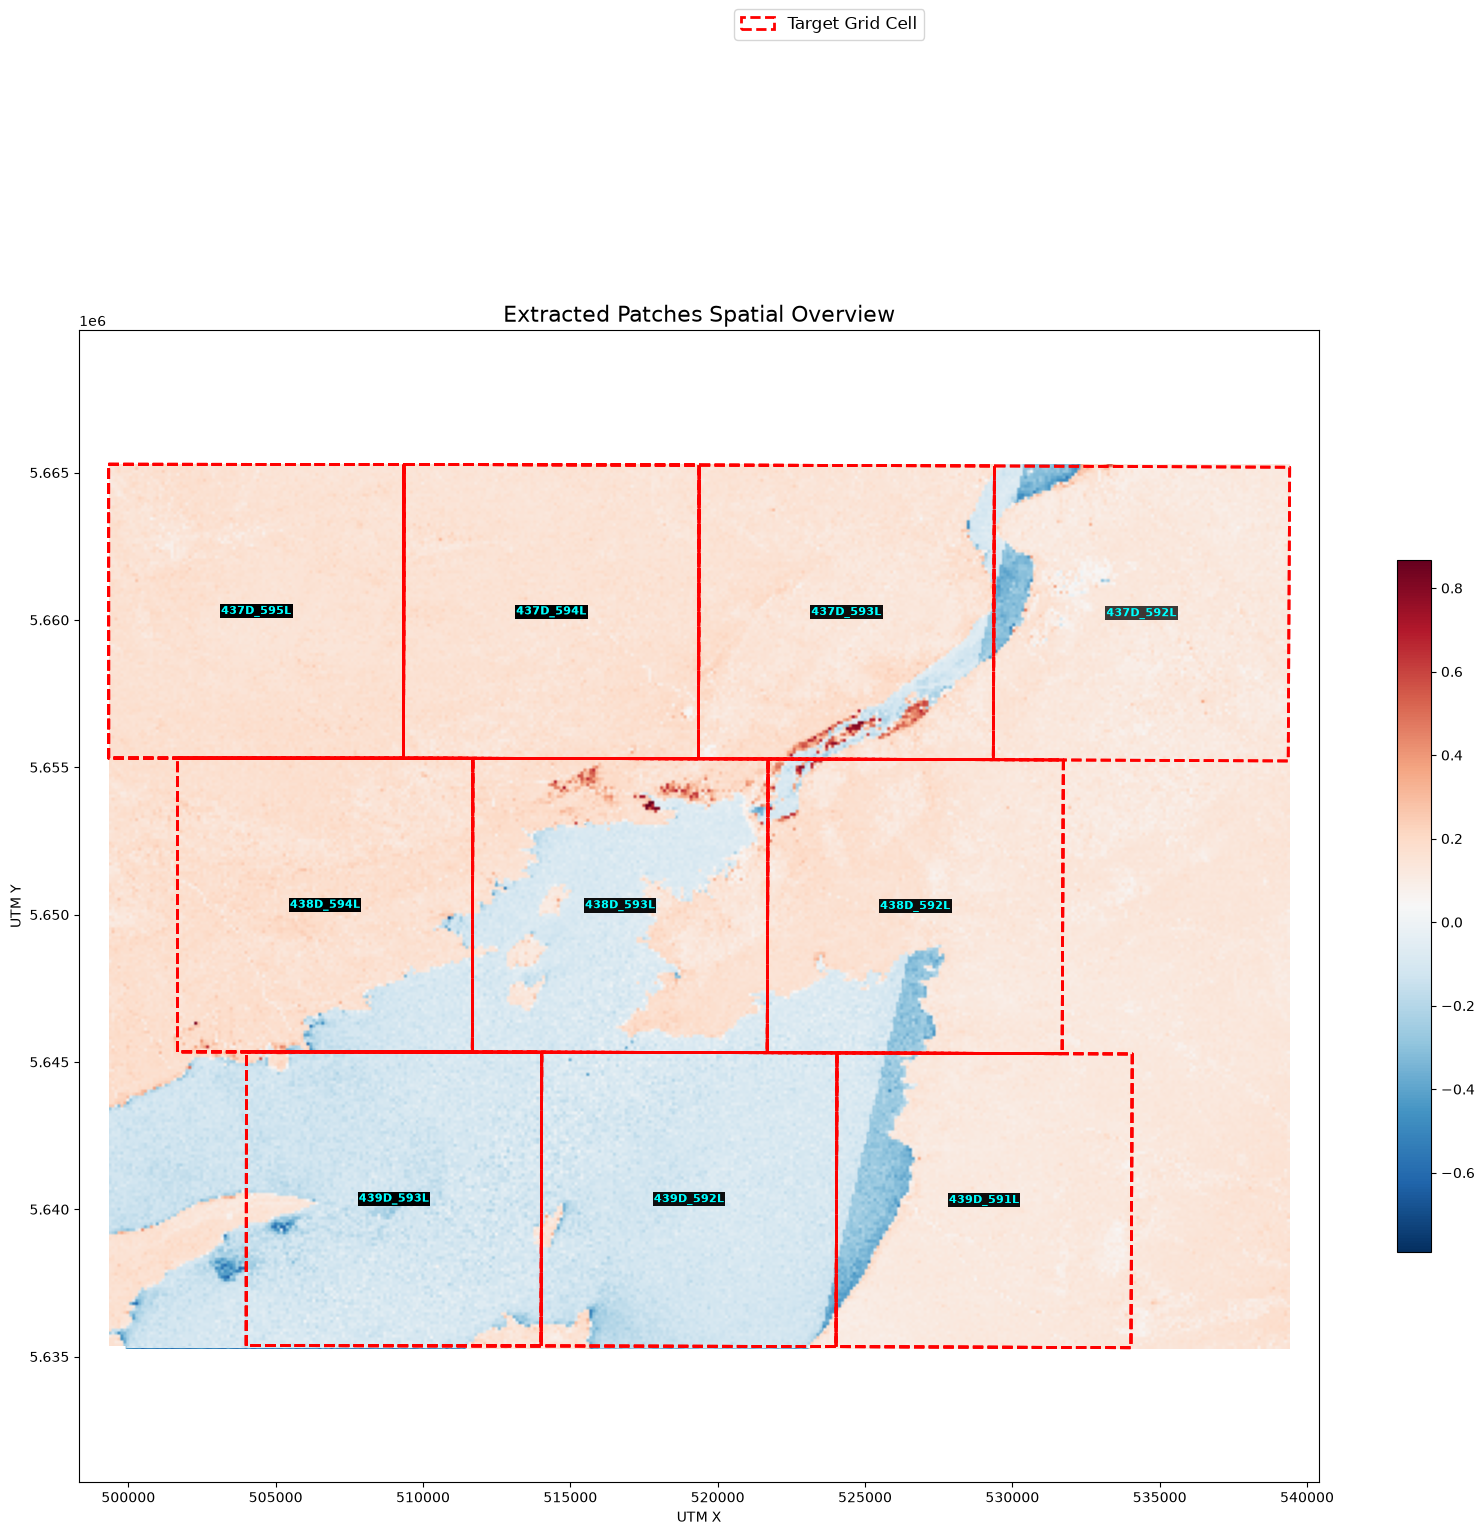

In [6]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, ds_factor=10, cmap="RdBu_r")